<a href="https://colab.research.google.com/github/rodrigodandrea/crypto-volatility-analyzer/blob/main/correlation_and_volatility_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalamos la librería para bajar datos de mercado
!pip install yfinance

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Definimos los activos y el período
assets = ['BTC-USD', 'ETH-USD']
data = yf.download(assets, start='2025-01-01', end='2026-02-28')['Close']

# Limpiamos los datos (como hacías con SQL)
# Vamos a ver las primeras filas
data.dropna(inplace=True)
data.head()

/tmp/ipykernel_624/3011961685.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start='2025-01-01', end='2026-02-28')['Close']
[*********************100%***********************]  2 of 2 completed


Ticker,BTC-USD,ETH-USD
Date,,
2025-01-01,94419.757812,3353.504150
2025-01-02,96886.875000,3451.392578
2025-01-03,98107.429688,3605.009766
2025-01-04,98236.226562,3657.706787
2025-01-05,98314.960938,3634.103760


In [7]:
# Calculamos el cambio porcentual diario (Retornos)
returns = data.pct_change().dropna()

# Calculamos la volatilidad (Desviación Estándar)
volatility = returns.std() * (252**0.5) # Anualizada

print("Volatilidad Anualizada:")
print(volatility)

Volatilidad Anualizada:
Ticker
BTC-USD    0.379623
ETH-USD    0.637988
dtype: float64


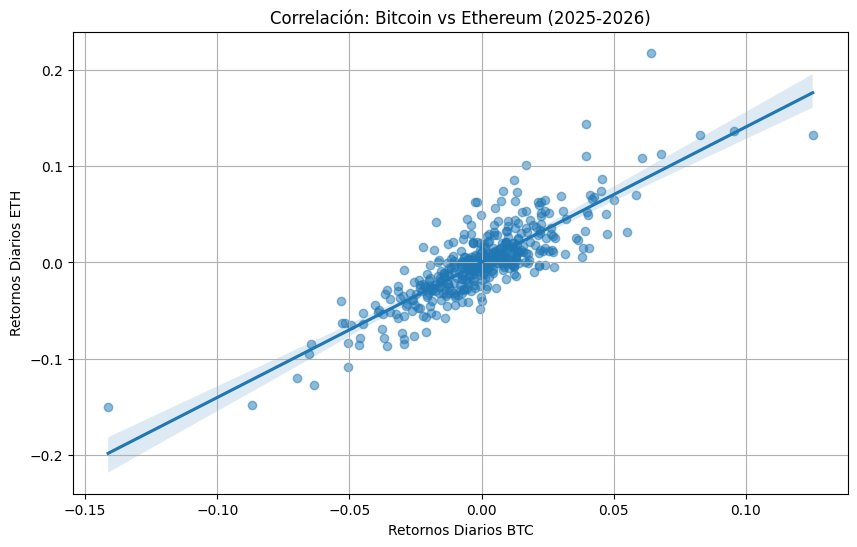

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(x=returns['BTC-USD'], y=returns['ETH-USD'], scatter_kws={'alpha':0.5})
plt.title('Correlación: Bitcoin vs Ethereum (2025-2026)')
plt.xlabel('Retornos Diarios BTC')
plt.ylabel('Retornos Diarios ETH')
plt.grid(True)
plt.show()